In [98]:
import numpy as np
import cv2

import PIL.Image as Image
import PIL
import os

import matplotlib.pylab as plt

import tensorflow as tf
import tensorflow_hub as hub

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

import warnings
warnings.filterwarnings("ignore")


In [99]:
IMAGE_SHAPE = (224, 224)

# 1. Load pre-trained MobileNetV2 directly from Keras (Modern way)
# This replaces the hub.KerasLayer entirely
classifier = tf.keras.Sequential([
    tf.keras.applications.MobileNetV2(
        input_shape=IMAGE_SHAPE + (3,),
        include_top=True,      # Keep the final classification layer
        weights='imagenet'      # Use pre-trained ImageNet weights
    )
])

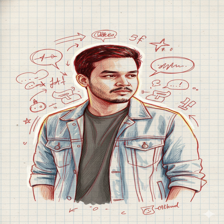

In [76]:
# 2. Process your image
gold_fish = Image.open("ImegeNet_test_img/Arka.png").resize(IMAGE_SHAPE)
gold_fish

# Note: MobileNetV2 expects pixel values to be preprocessed 
# (typically scaled between -1 and 1)

# x = tf.keras.utils.img_to_array(gold_fish)
# x = np.expand_dims(x, axis=0)
# x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

In [77]:
# gold_fish[np.newaxis, ...].shape

x = tf.keras.utils.img_to_array(gold_fish)
x = np.expand_dims(x, axis=0)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

In [78]:
predictions = classifier.predict(x)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


In [79]:
predictions.shape

(1, 1000)

In [80]:
predicted_label_index = np.argmax(predictions)
print(predicted_label_index)

697


In [81]:
with open("datasets/imagenetLabels.txt", "r") as f:
    image_labels = f.read().splitlines()
image_labels[:6]

['{',
 '  "0": "tench, Tinca tinca",',
 '  "1": "goldfish, Carassius auratus",',
 '  "2": "great white shark, white shark, man-eater, man-eating shark, Carcharodon carcharias",',
 '  "3": "tiger shark, Galeocerdo cuvieri",',
 '  "4": "hammerhead, hammerhead shark",']

In [82]:
image_labels[predicted_label_index]

'  "696": "paintbrush",'

In [83]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url,  cache_dir='.', untar=True)
data_dir

'.\\datasets\\flower_photos'

In [92]:
import pathlib
data_dir = pathlib.Path(data_dir)
data_dir

WindowsPath('datasets/flower_photos')

In [93]:
list(data_dir.glob('*/*.jpg'))[:5]

[WindowsPath('datasets/flower_photos/daisy/100080576_f52e8ee070_n.jpg'),
 WindowsPath('datasets/flower_photos/daisy/10140303196_b88d3d6cec.jpg'),
 WindowsPath('datasets/flower_photos/daisy/10172379554_b296050f82_n.jpg'),
 WindowsPath('datasets/flower_photos/daisy/10172567486_2748826a8b.jpg'),
 WindowsPath('datasets/flower_photos/daisy/10172636503_21bededa75_n.jpg')]

In [94]:
image_count = len(list(data_dir.glob('*/*.jpg')))
print(image_count)

3670


In [95]:
roses = list(data_dir.glob('roses/*'))
roses[:5]

[WindowsPath('datasets/flower_photos/roses/10090824183_d02c613f10_m.jpg'),
 WindowsPath('datasets/flower_photos/roses/102501987_3cdb8e5394_n.jpg'),
 WindowsPath('datasets/flower_photos/roses/10503217854_e66a804309.jpg'),
 WindowsPath('datasets/flower_photos/roses/10894627425_ec76bbc757_n.jpg'),
 WindowsPath('datasets/flower_photos/roses/110472418_87b6a3aa98_m.jpg')]

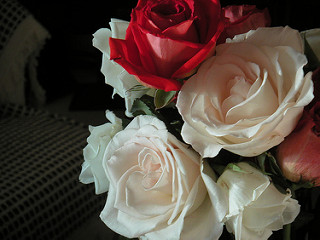

In [100]:
PIL.Image.open(str(roses[1]))

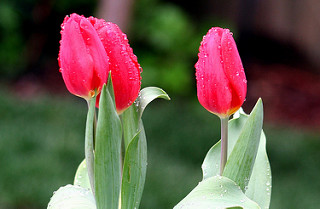

In [101]:
tulips = list(data_dir.glob('tulips/*'))
PIL.Image.open(str(tulips[0]))

### Read flowers images from disk into numpy array using opencv

In [102]:
flowers_images_dict = {
    'roses': list(data_dir.glob('roses/*')),
    'daisy': list(data_dir.glob('daisy/*')),
    'dandelion': list(data_dir.glob('dandelion/*')),
    'sunflowers': list(data_dir.glob('sunflowers/*')),
    'tulips': list(data_dir.glob('tulips/*')),
}

In [103]:
flowers_labels_dict = {
    'roses': 0,
    'daisy': 1,
    'dandelion': 2,
    'sunflowers': 3,
    'tulips': 4,
}

In [104]:
flowers_images_dict['roses'][:5]

[WindowsPath('datasets/flower_photos/roses/10090824183_d02c613f10_m.jpg'),
 WindowsPath('datasets/flower_photos/roses/102501987_3cdb8e5394_n.jpg'),
 WindowsPath('datasets/flower_photos/roses/10503217854_e66a804309.jpg'),
 WindowsPath('datasets/flower_photos/roses/10894627425_ec76bbc757_n.jpg'),
 WindowsPath('datasets/flower_photos/roses/110472418_87b6a3aa98_m.jpg')]

In [111]:
str(flowers_images_dict['roses'][0])

'datasets\\flower_photos\\roses\\10090824183_d02c613f10_m.jpg'

In [106]:
img = cv2.imread(str(flowers_images_dict['roses'][0]))

In [107]:
cv2.resize(img,(224,224)).shape

(224, 224, 3)

In [108]:
X, y = [], []

for flower_name, images in flowers_images_dict.items():
    for image in images:
        img = cv2.imread(str(image))
        resized_img = cv2.resize(img,(224,224))
        X.append(resized_img)
        y.append(flowers_labels_dict[flower_name])

In [109]:
X = np.array(X)
y = np.array(y)

### Train test split

In [110]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

### Preprocessing: scale images

In [112]:
X_train_scaled = X_train / 255
X_test_scaled = X_test / 255

Make prediction using pre-trained model on new flowers dataset

In [113]:
X[0].shape
IMAGE_SHAPE+(3,)

(224, 224, 3)

In [114]:
x0_resized = cv2.resize(X[0], IMAGE_SHAPE)
x1_resized = cv2.resize(X[1], IMAGE_SHAPE)
x2_resized = cv2.resize(X[2], IMAGE_SHAPE)

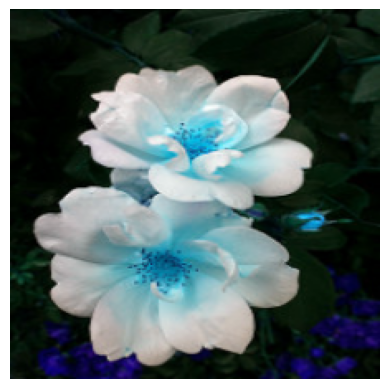

In [115]:
plt.axis('off')
plt.imshow(X[0])

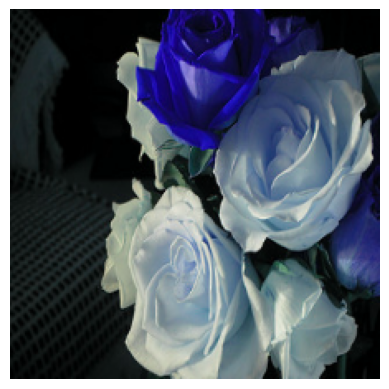

In [116]:
plt.axis('off')
plt.imshow(X[1])

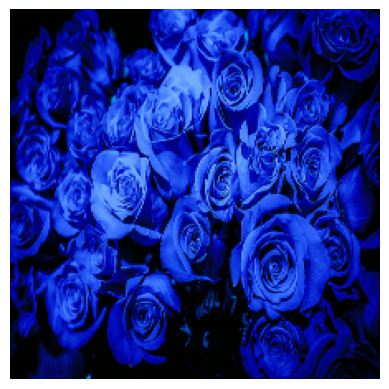

In [117]:
plt.axis('off')
plt.imshow(X[2])

In [118]:
predicted = classifier.predict(np.array([x0_resized, x1_resized, x2_resized]))
predicted = np.argmax(predicted, axis=1)
predicted

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


array([794, 721, 443])

In [119]:
image_labels[795]

'  "794": "shower curtain",'

### Now take pre-trained model and retrain it using flowers images

In [120]:
feature_extractor_model = "https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4"

pretrained_model_without_top_layer = hub.KerasLayer(
    feature_extractor_model, input_shape=(224, 224, 3), trainable=False)

In [122]:
num_of_flowers = 5
img_shape = (224, 224, 3) # Standard size for MobileNetV2

# 1. Load the pre-trained model from keras.applications
# include_top=False removes the final 1000-class classification layer
base_model = tf.keras.applications.MobileNetV2(
    input_shape=img_shape,
    include_top=False, 
    weights='imagenet',
    pooling='avg' # This replaces the need for a Flatten layer
)

# 2. Freeze the base model (Transfer Learning 101)
base_model.trainable = False

# 3. Build the Sequential model
model = tf.keras.Sequential([
  base_model,
  tf.keras.layers.Dense(num_of_flowers, activation='softmax')
])

model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 1280)                │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 5)                   │           6,405 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [123]:
model.evaluate(X_test_scaled,y_test)

ValueError: You must call `compile()` before using the model.